Randomised Riemannian Hamiltonian Monte Carlo for Bayesian Estimation as a Constrained Distribution Problem

Defined by $g(X,d_{1},d_{2}) = X^{T}X - \mathbb{I}_{p} = 0$, we have $\mathcal{M} := \{(X,d_1 , d_2 ) \in \mathbb{R}^{d \times p}\times \mathbb{R}^{p} \times \mathbb{R}^d \mid g(X) = 0\}$

For $A \in \mathbb{R}^{d \times p}$ with $v_{i} \in \mathbb{R}^{d}$, $i = 1,...,p$ being the column vectors. We define $g_{ij}(A) = v_{i} \cdot v_{j} - \delta_{ij} = 0$


1) Dynamics

In [1]:
import numba
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random

# Data Extraction

In [2]:
import os
from os import sys

In [3]:
data_matrix = np.zeros((120,2000))


for k in range(1,2001):
    file_location = './cov_shrink_simulations/'
    if k < 10:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
    
    if 10 <= k < 100:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2              =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
        
    if 100 <= k < 1000:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    if 1000 <= k:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    temp12  = np.append(temp1, temp2, axis = 0)
    temp123 = np.append(temp12,temp3, axis = 0)
    #print(np.shape(temp123))
    data_matrix[:,k-1]  = np.reshape(temp123,(len(temp123),))
        


In [4]:
# Astronomical Data
n = 2000
N = 120

In [5]:
Data = data_matrix

# Toy Example

In [6]:
N = 120
σ_1 = 5
σ_2 = 1

Data = np.zeros((N,2000))
for i in range(2000):
    for j in range(N//2):
        Data[j,i] = np.random.normal(0,σ_1)
        Data[j+N//2,i] = np.random.normal(0,σ_2)  

We are sampling from the von Mises-Fisher distribution which has density given by 

$p_{vMF}(X) \propto \exp{(\langle f_{1},x_{1} \rangle + ... + \langle f_{p},x_{p}\rangle)}$

In [7]:
#p<=d



p =  20
d =  N
m =  p

n = 80

dimension = int(d*p+p+d)
num_of_constraints  = int(p*(p+1)/2)

σ_1 = 25
σ_2 = 100
#Matrix in distribution

@numba.jit(nopython=True)
def vec_to_matrix(q):
    X = np.zeros((d,p))
    for i in range(d):
        for j in range(p):
            X[i,j] = q[j*d+i]
    return X

@numba.jit(nopython=True)
def matrix_to_vec(X):
    #initialising filler array
    x = np.zeros(d*p)
    
    for i in range(d*p):
        i_index = i%d
        j_index =  int((i - i_index)/d)
        x[i] = X[i_index,j_index]
    return x

@numba.jit(nopython=True)
def dot_product(v1,v2):
    dot = 0
    for i in range(len(v1)):
        
        dot += v1[i]*v2[i]
        
    return dot

@numba.jit(nopython=True)
def matmul(matrix1,matrix2):
    a = matrix1.shape[0]
    b = matrix2.shape[1]
    c = matrix2.shape[0]
    rmatrix = np.zeros((a,b))
    for i in range(a):
        for j in range(b):
            for k in range(c):
                rmatrix[i,j] += matrix1[i,k] * matrix2[k,j]
    return rmatrix

@numba.jit(nopython=True)
def matrix_vec_multiplication(A,x):
    v = np.zeros(len(A))
    
    for i in range(len(A)):
        for j in range(len(x)):
                v[i] += A[i][j] * x[j]
    return v


@numba.jit(nopython=True)
def g_ij(q,i,j):
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    if i==j:
        y = np.linalg.norm(X[:,i])**2 - 1
    else:
        y = dot_product(X[:,i],X[:,j])
        
    return y


@numba.jit(nopython=True)
def G(q): #considering i<j.
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    z = np.zeros((dimension,num_of_constraints))
    
    for i in range(p): #block diagonals
        z[d*i:d*(i+1),int(p*i-0.5*i*(i-1)):int(p*(i+1) - 0.5*i*(i+1))] = X[:,i:]
    
        #vector diagonals
        for j in range(p-i):
            z[(j+i)*d:(j+i+1)*d,int(p*i-0.5*i*(i-1) + j)] += X[:,i]  
    z = z.T #could implement this above
    return z


In [8]:
@numba.jit(nopython=True)
def potential_derv(q):
    #Can check with numerical differentiation.
    
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    
    Σ_inv_T = np.transpose(np.linalg.inv(Σ))

    #Constructing B
    B = np.zeros((d,d,d,d))
    for k in range(d):
        for l in range(d):
            for i in range(d):
                for j in range(d):
                    B_klij = -Σ_inv_T[k,i]*Σ_inv_T[j,l]
                    B[k,l,i,j] = B_klij
    
    #dUdX
    dUdX = np.zeros((d,p))
    
    for i in range(d):
        
        for j in range(p):
            
            for k in range(d):
                
                for l in range(d):
                    
                    if k == i and l == i:
                        
                        dΣ_kl_dX_ij = 2*X[i,j]*d_1[j]
                        
                    elif k == i:
                        
                        dΣ_kl_dX_ij = d_1[j]*X[l,j]
                        
                    elif l == i:
                        
                        dΣ_kl_dX_ij = X[k,j]*d_1[j]
                    
                    else:
                        continue
                    
                    sum_term = 0.
                    
                    for nn in range(n):
                    
                        Bx = matrix_vec_multiplication(B[k,l,:,:],Data[:,nn])
                        sum_term += dot_product(Data[:,nn],Bx)
                    
                    dUdX[i,j] += (0.5*n*Σ_inv_T[k,l]+0.5*sum_term)*dΣ_kl_dX_ij
                    
                
            
    
    #dUd1
    dUd1 = np.zeros(p)
    
    for j in range(p):
    
        for k in range(d):
                
            for l in range(d):
                    
                    
                dΣ_kl_dD1_jj = X[k,j]*X[l,j]

                sum_term = 0.

                for nn in range(n):

                    Bx = matrix_vec_multiplication(B[k,l,:,:],Data[:,nn])
                    sum_term += dot_product(Data[:,nn],Bx)

                dUd1[j] += (0.5*n*Σ_inv_T[k,l]+0.5*sum_term)*dΣ_kl_dD1_jj

        #adding extra term
        dUd1[j] += d_1[j]/(σ_1)**2
    
   
    #dUd2
    dUd2 = np.zeros(d)
    
    for j in range(d):
    
        sum_term = 0.

        for nn in range(n):

            Bx = matrix_vec_multiplication(B[j,j,:,:],Data[:,nn])
            sum_term += dot_product(Data[:,nn],Bx)

        dUd2[j] += (0.5*n*Σ_inv_T[j,j]+0.5*sum_term)*1.
        
        #adding extra term
        dUd2[j] += d_2[j]/(σ_2)**2
    
    pot_derv = np.zeros(int(d*p+p+d))
    pot_derv[:d*p] = matrix_to_vec(dUdX)
    pot_derv[d*p:d*p+p] = dUd1
    pot_derv[d*p+p:] = dUd2
    
    return pot_derv

In [9]:
@numba.jit(nopython=True)
def potential_derv_fast(q):
    #Can check with numerical differentiation.
    
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    
    Σ_inv_T = np.transpose(np.linalg.inv(Σ))

    #Constructing M
    M_kl = 0.5*n*Σ_inv_T 
    
    for k in range(d):
        for l in range(d):
            for r in range(n):
                M_kl[k,l] -= 0.5*dot_product(Data[:,r],Σ_inv_T[k,:])*dot_product(Σ_inv_T[:,l],Data[:,r])
    
    #dUdX
    dUdX = np.zeros((d,p))
    
    for i in range(d):
        
        for j in range(p):
            
            for k in range(d):
                
                for l in range(d):
                    
                    if k == i and l == i:
                        
                        dΣ_kl_dX_ij = 2*X[i,j]*d_1[j]
                        
                    elif k == i:
                        
                        dΣ_kl_dX_ij = d_1[j]*X[l,j]
                        
                    elif l == i:
                        
                        dΣ_kl_dX_ij = X[k,j]*d_1[j]
                    
                    else:
                        continue
                    
                    dUdX[i,j] += M_kl[k,l]*dΣ_kl_dX_ij
                    
                
            
    
    #dUd1
    dUd1 = np.zeros(p)
    
    for j in range(p):
    
        for k in range(d):
                
            for l in range(d): 
                    
                dΣ_kl_dD1_jj = X[k,j]*X[l,j]

                dUd1[j] += M_kl[k,l]*dΣ_kl_dD1_jj

        #adding extra term
        dUd1[j] += d_1[j]/(σ_1)**2
    
   
    #dUd2
    dUd2 = np.zeros(d)
    
    for j in range(d):

        dUd2[j] += M_kl[j,j]*1.
        
        #adding extra term
        dUd2[j] += d_2[j]/(σ_2)**2
    
    pot_derv = np.zeros(int(d*p+p+d))
    pot_derv[:d*p] = matrix_to_vec(dUdX)
    pot_derv[d*p:d*p+p] = dUd1
    pot_derv[d*p+p:] = dUd2
    
    return pot_derv

In [10]:
q_initial = list(matrix_to_vec(np.eye(d,p)))
d_1 = abs(np.random.normal(0,σ_1,p))
d_2 = abs(np.random.normal(0,σ_2,d))
q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
#x_init = q_initial
print(q_initial)

[  1.           0.           0.         ... 131.4217557   11.67246615
 130.04396905]


In [11]:
# t1 = time.time()
# potential_derv(q_initial)
# t2 = time.time()
# print('time before compiling = ',t2-t1)
# t1 = time.time()
# potential_derv(q_initial)
# t2 = time.time()
# print('time after compiling = ',t2-t1)

In [12]:
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  2.547795295715332
time after compiling =  0.41214847564697266


In [13]:
#RATTLE Hamiltonian Flow
@numba.jit(nopython=True)
def RATTLE_with_Potential(x0,v0,t,dt,max_elim_iters):
    n = np.floor(t/dt)
    vn = v0
    qn = x0
    vhalf = v0
    G_q = G(qn)
    
    #Gram Matrix is GG^T
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    
    
    pderv = potential_derv_fast(qn)#potential_derv(qn)
    
    residual_list = np.zeros(num_of_constraints)
    for i in range(int(n)):
        
        
        #solver for Lagrange position multipliers
        Q = qn + vn*dt - 0.5*dt*dt*pderv
        
        #non-linear gaussian elimination
        for k in range(max_elim_iters): #i>j
            for i in range(p):
                for j in range(i,p):
                    g_Q = g_ij(Q,i,j)
                    index = int(i*p - 0.5*i*(i-1) + j-i)
                    
                    residual_list[index] = g_Q
                    if abs(g_Q) < 1e-8:
                        continue
                    G_Q = G(Q)
                    
                    #should be sum of i's and js in indexing below
                    dlambda = g_Q/dot_product(G_Q[index,:],G_q[index,:])
                    Q = Q - G_q[index,:]*dlambda
            #break condition
            if np.all(np.abs(residual_list)<1e-8):
                break

        
        #half step
        vhalf = (Q-qn)/dt
        qn = Q
        
        pderv = potential_derv_fast(qn) #potential_derv(qn)
        G_q = G(qn)
        
        gram = matmul(G_q,G_q.T)
        gram_inv = np.linalg.inv(gram)
        
        #linear solver Lagrange velocity multipliers
        b = matrix_vec_multiplication(G_q,2*vhalf/dt - pderv)
        coeffs_v = matrix_vec_multiplication(gram_inv,b)
        
        #full step
        vn = vhalf - 0.5*dt*pderv - 0.5*dt*matrix_vec_multiplication(G_q.T,coeffs_v)
       
    return qn,vn

# Checks

In [14]:
X = np.array([[1,2,3], [4,5,6],[7,8,9]])
#print(X[:,1:])
#g_ij checked
#G checked for what I want.
#print(X.T,X)
M = np.eye(d, p)
M = matrix_to_vec(M)
gram = matmul(G(M),G(M).T)
"G matrix should be #constraints by dimension 0.5*p*(p+1) by p*d" 
#6 by 9
print(gram)
M = np.eye(d, p)


[[4. 0. 0. ... 0. 0. 0.]
 [0. 2. 0. ... 0. 0. 0.]
 [0. 0. 2. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 4. 0. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 0. ... 0. 0. 4.]]


2) Event Time Sampling


In [15]:
#Sampling Event Times
@numba.jit(nopython=True)
def time_exp(lam):
    t = np.random.exponential(lam)
    return t

3) Gaussian Sampling on Tangent Space

In [16]:
@numba.jit(nopython=True)
def tangent_space_gaussian(q):
    
    
    v = np.random.normal(0.,1.0,dimension).T
    
    
    G_q = G(q)
    
    
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    proj_matrix = np.eye(dimension) - matmul(G_q.T,matmul(gram_inv,G_q))
    
    #sample 3d gaussian and then project onto tangent space.
    v = matrix_vec_multiplication(proj_matrix,v)
    
    return v

#check
q_initial = list(matrix_to_vec(np.eye(d,p)))
q_initial += list(np.ones(d + p))
q_initial = np.array(q_initial)
Z = tangent_space_gaussian(q_initial)
T_X = vec_to_matrix(Z[:d*p])  
X = vec_to_matrix(q_initial[:d*p])
print('constraint check =',matmul(T_X.T,X) + matmul(X.T,T_X))
print('Should be Gaussian no constraints =',Z[d*p:])

constraint check = [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [17]:

t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  10.52708888053894
time after compiling =  8.253320932388306


In [18]:
@numba.jit(nopython=True)
def U(q):
    
    X = vec_to_matrix(q[:d*p])
    
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    Σ_inv = np.linalg.inv(Σ)
    
    #likelihood
    pot = 0.5*n*np.log(np.linalg.det(Σ)) + 0.5*n*p*np.log((2*np.pi))
    for i in range(n):
        Bx = matrix_vec_multiplication(Σ_inv,Data[:,i])
        pot += 0.5*dot_product(Data[:,i],Bx)
        
    #prior
    #don't need uniform prior because it's constant
    pot += 0.5*np.log(2*np.pi*(σ_1)**2)
    pot += 0.5*dot_product(d_1,d_1)/(σ_1)**2
    
    pot += 0.5*np.log(2*np.pi*(σ_2)**2)
    pot += 0.5*dot_product(d_2,d_2)/(σ_2)**2
    
    return pot


@numba.jit(nopython=True)
def f(q):
    
    z = U(q)
    
    return z

@numba.jit(nopython=True)
def hamiltonian(x,v):
    return f(x) + 0.5*dot_product(v,v)

In [19]:
def Potential_approx_deriv(q,ϵ):
    δV = np.zeros(len(q))
    for i in range(len(q)):
        h = np.zeros(len(q))
        h[i] = ϵ
        δV[i] = (U(q+h)-U(q-h))/(2*ϵ)
    return δV

In [20]:
# print(U(q_initial))
# t1 = time.time()
# p1 = potential_derv(q_initial)
# t2 = time.time()
# p2 = Potential_approx_deriv(q_initial,0.0001)
# t3 = time.time()
# print('sup|grad_exact - grad_num| =',max(p2-p1))
# print('Exact time = ',t2-t1)
# print('Numerical time = ',t3-t2)

In [21]:
print(U(q_initial))
t1 = time.time()
p1 = potential_derv_fast(q_initial)
t2 = time.time()
p2 = Potential_approx_deriv(q_initial,0.0001)
t3 = time.time()
print('sup|grad_exact - grad_num| =',max(p2-p1))
print('Exact time = ',t2-t1)
print('Numerical time = ',t3-t2)

55255.49097604696
sup|grad_exact - grad_num| = 1.932112922986562e-06
Exact time =  0.34280943870544434
Numerical time =  15.695831298828125


4) Simulation

In [22]:
#Initialise
T = 0.1
num_of_events = 3
dt = 0.001

In [23]:
# x_init = [0.4404492658152824, 0.4356498571485722, 0.17257437658462882, 0.09393965526901421, 0.15363512153258765, -0.06186908927654128, 0.05395134007000949, 0.2923365217815789, 0.2460770624210223, 0.14846050412734996, -0.3739590693237175, -0.09120846004272248, 0.15392871615340487, 0.205697201182686, -0.1541055354910055, -0.10588484018952184, 0.051701886606157474, 0.12858233564909108, -0.05795797209703186, 0.09783644645173949, 0.01883339138677387, -0.2775854732763347, 0.040558721955369276, 0.021471998621644846, 0.08267436379273854, -0.07762897145582436, -0.020242968655770032, 0.060321054879674346, 0.027342897909841214, -0.027756769103604202, -0.1168383694119314, 0.5541224261517362, -0.3185807696488106, 0.06077409486256003, 0.09723891538055061, 0.15646889912298087, -0.02854111549524369, 0.2596552559390685, 0.13909720178181756, -0.4155656348710471, 0.1958562491147557, -0.15374508058419561, -0.301193562356173, -0.20647914636950457, 0.23348683059916706, 0.0043121159579476, -0.06215459340169219, -0.024319311533967814, -0.013421868646932275, 0.024494467863970474, 0.09540257040020939, 0.028111732993103062, -0.0548083145037731, 0.07466784351559883, 0.025394257019767063, 0.007206452704310917, -0.008517216712831855, 0.036352544499956195, -0.032824443052557474, 0.0560037528441778, -0.03359503638895968, 0.26214541904960886, 0.3450974045024755, 0.005308824899569488, -0.491874692573486, -0.05910255737493421, -0.36194764311619715, -0.0906909458724739, -0.09716561317285538, -0.01594569079342932, -0.3444960395269137, 0.14502098901655208, -0.048318185562437596, -0.44381840071807493, 0.121802739468376, 0.021638402986422847, -0.06126382735082417, -0.06852383555955086, -0.0789374505425249, -0.1310342460351157, -0.06476951973312639, -0.07533247862749368, -0.019364465784569473, -0.07959107086158686, 0.031278777751386565, 0.04440726276515563, 0.058812928193303575, -0.05686794749319871, -0.05093496964813692, 0.04100098348741837, 0.050856629177651075, 0.005091247383611008, -0.04075460654028009, 0.5573354372220526, 0.0015245216771957346, 0.10455357232705516, 0.17751333126130672, 0.1351350506482967, -0.6894253292716083, 0.037150446421039304, -0.1238379623998595, -0.1391753761180293, -0.2128632439689516, 0.018330401606865124, -0.15053313835584714, 0.021446013733129914, 0.028450768886616545, 0.03702700331611641, -0.1385537787998094, -0.07551932288846937, -0.007596806459487328, -0.019972937902453275, -0.07117190528461262, 0.00712329542550734, -0.07199515547471771, 0.026104047789394024, 0.03726557619877736, 0.0037378133859175856, -0.05660063044602308, -0.03336322729037095, -0.18876382270466563, -0.026670298078553284, 0.06492882635409006, 0.25335207947537136, 0.5366390154253031, -0.014665823234112566, 0.3126250333279615, -0.24050753949523332, 0.16220373301898272, 0.07052245531878802, -0.3257509850804925, 0.11037479585327625, 0.10763796295509814, -0.3920105583005507, 0.2863103858178462, 0.10935705031139158, 0.03062621472140119, -0.11609835361930074, -0.016123678107653343, 0.012954558339685228, -0.11826547431689784, -0.02241616020166476, 0.030875758157584126, 0.07389665587621667, -0.01963560324069021, 0.049312726746372534, 0.020105863731596632, -0.03672805335293831, -0.037262293917630696, -0.031649694818262485, 3.789574099820256, 4.966913614739519, 4.244603929999138, 4.3488720561327945, 5.013803680528581, 6.2242855674375415, 5.564853366082504, 5.521633393932421, 5.9827314861442975, 5.715769118642915, 7.460969762636731, 6.753668135336583, 6.233201233696593, 6.939113153614891, 6.579871300225151, 6.651731389790793, 6.9810141753939154, 5.862543390274761, 6.806021874820919, 5.912948493277419, 0.8337856158531566, 1.2026391097735405, 0.8875304077333692, 0.9045860356566013, 0.8627205389048449, 0.9945982648836925, 0.7431819801283314, 1.0060009218060113, 0.7472124056922372, 1.3622618299688913, 0.9269678542688913, 0.756263809451602, 0.763472905179133, 0.7967144828836346, 0.6761563175281055]
# x_init = np.array(x_init)

x_init = list(matrix_to_vec(np.eye(d,p)))
x_init += list(np.ones(p))
x_init += list(25*np.ones(d//2))
x_init += list(np.ones(d//2))
x_init = np.array(x_init)

print(x_init)


[1. 0. 0. ... 1. 1. 1.]


In [24]:
@numba.jit(nopython=True)
def RRHMC(num_of_events,N,T,x_init):
    
    #Exponential Expected Value
    rate = T
    
#     x = list(matrix_to_vec(np.eye(d,p)))
#     x += list(np.ones(d + p))
    x = x_init
    
    #initialisation of x on V_{d,p} \times \mathbb{R}^p 
    #                        \times \mathbb{R}^d
    
    v = tangent_space_gaussian(x)
    
    position_list = [x]
    
    
    for i in range(num_of_events):
        
        dt = time_exp(rate/N)
        t = dt*N
        h = hamiltonian(x,v)
    
        xnew,vnew = RATTLE_with_Potential(x,v,t,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #adding in rejection for non-positive diagonal matrices.
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
            

        
        position_list.append(x)
        
        v = tangent_space_gaussian(x)
        if i%10==0:
            print(i)
        
        
    return position_list

In [25]:
@numba.jit(nopython=True)
def RHMC(num_of_events,dt,T,x_init):
    
#     x = list(matrix_to_vec(np.eye(d,p)))
#     x += list(np.ones(d + p))
    x = x_init
    #initialisation of x on V_{d,p} \times \mathbb{R}^p 
    #                        \times \mathbb{R}^d
    v = tangent_space_gaussian(x)
    
    position_list = [x]
    
    
    for i in range(num_of_events):
        
        h = hamiltonian(x,v)
        
        xnew,vnew = RATTLE_with_Potential(x,v,T,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #with reject with positivity constraint
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
        
        position_list.append(x)
        v = tangent_space_gaussian(x)  
        if i%10==0:
            print(i)
            
    return position_list

In [26]:
t = time.time()
position = RRHMC(num_of_events,T/dt,T,x_init)
elapsed = time.time() - t
print('RT time =',elapsed)
t = time.time()
position = RHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('DT time =',elapsed)

0
RT time = 239.71855092048645
0
DT time = 243.26568722724915


# Check

In [27]:
@numba.jit(nopython=True)
def f(q):
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    return Σ

In [28]:
#Initialise
#T = 0.1
num_of_events = 10000
dt = 0.001
N = 10
T = N*dt
#ensure positivity
#log normal prior

In [29]:
position = RRHMC(num_of_events,N,T,x_init)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090
2100
2110
2120
2130
2140
2150
2160
2170
2180
2190
2200
2210
2

In [30]:
x_init = list(position[-1])
print(x_init)

[-0.07974147913737195, -0.04800848027176572, 0.03684695523912792, 0.013528514193960658, -0.008059216957748814, 0.0825820079642419, 0.09190066438421016, -0.022094873677357442, -0.050010014098091686, -0.12142868381828145, 0.05789031069072152, 0.16828527779386268, -0.07548343428860575, -0.14286474998796636, -0.03461405160506128, 0.06003925732485356, -0.032651664505944124, -0.04788547058253978, 0.000320909299700409, 0.10944712789529137, -0.0869117400838623, 0.09505080639104428, 0.049809703818546096, -0.04307025063928095, 0.07878707459264757, 0.17388285593722813, 0.03260211903698186, 0.008403782903263596, -0.08432418850655177, -0.08012439346833414, 0.08826058253009823, -0.010660915137626438, 0.07180664896902453, -0.10021111657120102, 0.0669729915872547, -0.02971108464680798, -0.0303802489016058, 0.06102231803932863, -0.0072363808082569194, -0.08949604246897859, 0.1938731686082888, -0.05842350168934753, 0.052462573857793536, 0.16321641839290757, 0.17489189619673973, 0.19758463642413904, 0.06

In [31]:
first_entry_list = []
first = 0
burn = 0
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    first += mat[0,0]
    first_entry_list.append(first/(i+1))

Text(0.5, 0, 'number of samples')

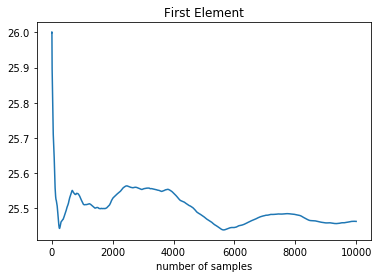

In [32]:
plt.plot(first_entry_list)
plt.title('First Element')
plt.xlabel('number of samples')

In [33]:
last_entry_list = []
last = 0
burn = 0
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    last += mat[-1,-1]
    last_entry_list.append(last/(i+1))

Text(0.5, 0, 'number of samples')

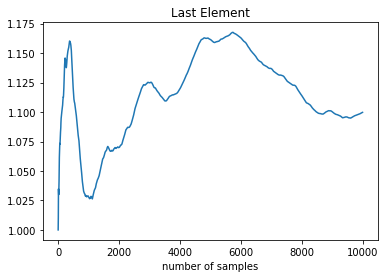

In [34]:
plt.plot(last_entry_list)
plt.title('Last Element')
plt.xlabel('number of samples')

In [57]:
burn = 0
Σ_ave = np.zeros((d,d))
for i in range(num_of_events-burn):
    Σ_ave += f(position[i+burn])/(num_of_events-burn)

In [79]:
S = Σ_ave
print(S)

[[ 2.54627859e+01  5.12033701e-03 -1.88891105e-03 ... -3.39455362e-03
  -4.06762809e-03  4.42867040e-03]
 [ 5.12033701e-03  2.57249800e+01 -1.08768677e-03 ... -2.87695621e-03
  -3.12966456e-03  1.36465084e-02]
 [-1.88891105e-03 -1.08768677e-03  2.51789321e+01 ...  2.94326337e-03
   1.49571949e-03  3.16041053e-03]
 ...
 [-3.39455362e-03 -2.87695621e-03  2.94326337e-03 ...  1.07898417e+00
  -1.00258991e-02  6.20392878e-03]
 [-4.06762809e-03 -3.12966456e-03  1.49571949e-03 ... -1.00258991e-02
   1.26539274e+00 -3.94036476e-03]
 [ 4.42867040e-03  1.36465084e-02  3.16041053e-03 ...  6.20392878e-03
  -3.94036476e-03  1.09971954e+00]]


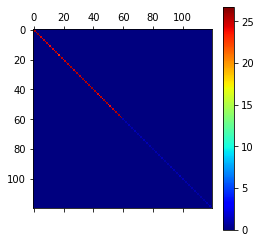

In [108]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.savefig('n=80-Sparse-Covariance',dpi=300, bbox_inches = "tight")
plt.show()
#4 before
#plot increase in maximum element

In [109]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

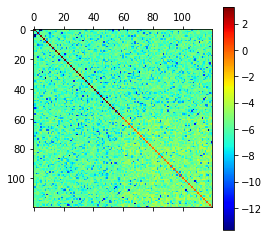

In [110]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [111]:
S_inv = np.linalg.inv(S)

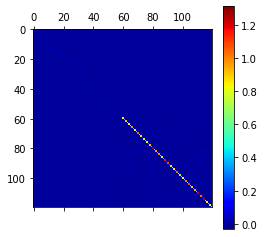

In [112]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [113]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

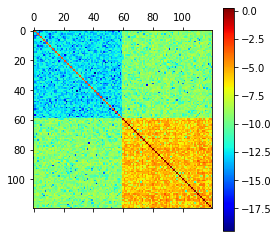

In [114]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# True Covariance Matrix

In [115]:
data_matrix = Data
mean = np.zeros(d)
for i in range(2000):
    mean += data_matrix[:,i]/2000

In [116]:
True_S = np.zeros((d,d))
for i in range(2000):
    x = data_matrix[:,i] - mean
    True_S += np.outer(x,x)/2000

In [117]:
print(True_S[-1,-1])
print(True_S[0,0])

0.9645846287103583
26.67187688280108


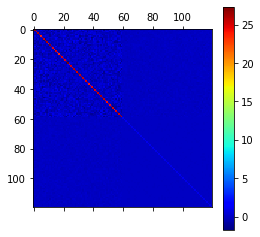

In [118]:
plt.matshow(True_S,cmap='jet')
plt.colorbar()
plt.savefig('n=2000-Sample-Covariance',dpi=300, bbox_inches = "tight")
plt.show()

In [119]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(True_S[i,j]))

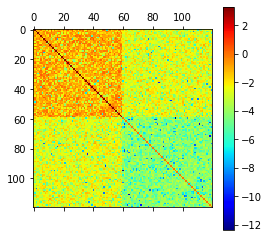

In [120]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [121]:
S_inv = np.linalg.inv(True_S)

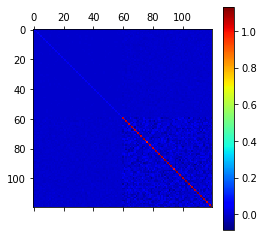

In [122]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [123]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

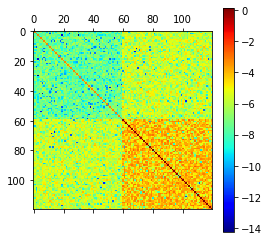

In [124]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# Using 80 points

In [125]:
data_matrix = Data
mean = np.zeros(d)
for i in range(80):
    mean += data_matrix[:,i]/80

In [126]:
S_small = np.zeros((d,d))
for i in range(80):
    x = data_matrix[:,i] - mean
    S_small += np.outer(x,x)/80

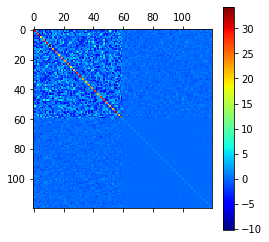

In [127]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.savefig('n=80-Sample-Covariance',dpi=300, bbox_inches = "tight")
plt.show()

In [132]:
True_S = np.diag(list(25*np.ones(d//2))+ list(np.ones(d//2)))

In [133]:
np.linalg.norm(True_S - Σ_ave,ord = 'fro')

6.00520681801239

In [136]:
np.linalg.norm(True_S - S_small,ord = 'fro')

178.52665627181236

In [135]:
#SNR

# SD in each component vs actual error

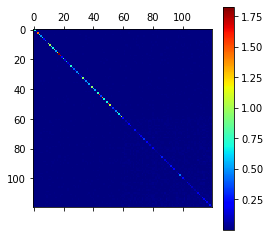

In [143]:
plt.matshow(abs(True_S - Σ_ave),cmap='jet')
plt.colorbar()
plt.show()

In [144]:
log_Σ_ABS_inv = np.zeros((d,d))
ABS_inv = np.linalg.inv(abs(True_S - Σ_ave))
for i in range(d):
    for j in range(d):
        log_Σ_ABS_inv[i,j] = np.log(abs(ABS_inv[i,j]))

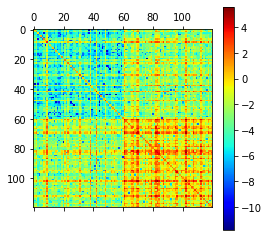

In [145]:
plt.matshow(log_Σ_ABS_inv,cmap='jet')
plt.colorbar()
plt.show()

In [146]:
burn = 0
Σ_SD = np.zeros((d,d))
for i in range(num_of_events-burn):
    Σ = f(position[i+burn])
    Σ_SD += (Σ**2 - Σ_ave**2)/(num_of_events-burn)

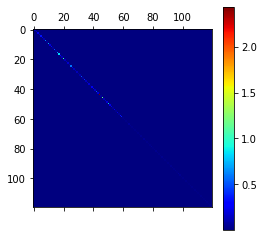

In [147]:
plt.matshow(Σ_SD,cmap='jet')
plt.colorbar()
plt.show()

In [148]:
log_Σ_SD_inv = np.zeros((d,d))
SD_inv = np.linalg.inv(Σ_SD)
for i in range(d):
    for j in range(d):
        log_Σ_SD_inv[i,j] = np.log(abs(SD_inv[i,j]))

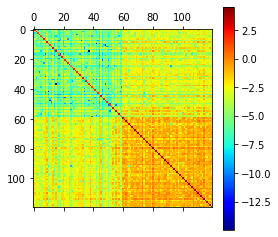

In [149]:
plt.matshow(log_Σ_SD_inv,cmap='jet')
plt.colorbar()
plt.show()